In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font size="6" color="red">02 딥러닝입문 분류분석</font></b>

In [3]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
import pandas as pd # 원핫인코딩
from tensorflow.keras.models import Sequential, load_model # 모델 생성, 모델 load
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 딥러닝 : 데이터의 규칙성을 추출
- 응용분야 : 글자인식, 문장분류, 예측, 질병진단, 얼굴인식
- ML/DL의 종류
    * 지도학습(독립=입력변수, 타겟=종속변수)
        * 분류분석(타겟변수가 category 변수인 분석. 다중분류 vs 이진분류) vs 회귀분석
    * 비지도학습(입력변수)
        * 군집화
    * 강화학습
- 지도학습에서의 딥러닝 프로그래밍 방식
    - 1. 데이터 확보 및 생성
    - 2. 데이터 전처리 : 스케일 조정, 훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋, 원핫인코딩
    - 3. 모델구성
    - 4. 모델 학습 과정 설정
    - 5. 모델 학습시키기(훈련, 검증데이터셋)
    - 6. 모델 평가하기(시험데이터셋)
    - 7. 모델 저장/사용(입력값이 주어지면 예측값을 받기) 

# 1. 데이터 셋 생성
# 2. 데이터 전처리

In [6]:
# 학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,4,6,8,10,12,14,16,18]*10)
# 검증데이터, 시험데이터셋
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val =np.array([2,4,6,8,10,12,14,16,18])

In [12]:
# 인코딩 (라벨인코딩=문자를 숫자[라벨]로, 원핫인코딩=라벨위치를 1 나머지는 0으로 표시)
data = np.array(['a','b','c','b','b'])
print('원데이터 :', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labeling_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :', labeling_data)
one_hot_encodiong_data = to_categorical(labeling_data)
print('원핫인코딩된 데이터 :\n', one_hot_encodiong_data)

원데이터 : ['a' 'b' 'c' 'b' 'b']
라벨인코딩된 데이터 : [0 1 2 1 1]
원핫인코딩된 데이터 :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [15]:
# 원핫인코딩(분류분석을 위한 target변수)
data = np.array([1,4,5,4,5])
categorical_onehot = to_categorical(data) # 원핫인코딩결과가 numpy배열
print('to_categorical 이용 \n', categorical_onehot)
getdummies_onehot = pd.get_dummies(data)
print('get_dummies 이용\n', getdummies_onehot)
print(type(categorical_onehot), type(getdummies_onehot))

to_categorical 이용 
 [[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
get_dummies 이용
    1  4  5
0  1  0  0
1  0  1  0
2  0  0  1
3  0  1  0
4  0  0  1
<class 'numpy.ndarray'> <class 'pandas.core.frame.DataFrame'>


In [18]:
# 분류분석을 위한 target변수 원핫인코딩
Y_train=to_categorical(y_train, 19)
Y_val =to_categorical(y_val)

In [20]:
x_train.shape, Y_train.shape, x_val.shape, Y_val.shape

((90,), (90, 19), (9,), (9, 19))

# 3. 모델구성

In [23]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(38, activation='sigmoid')) #활성화 함수:relu, elu, tanh, sigmoid
model.add(Dense(64, activation='elu'))
model.add(Dense(32, activation='elu'))
model.add(Dense(19, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정
- 회귀분석에서의 loss : mse, rmse, mae
- 분류분석에서의 loss : categorical_crossentropy

In [24]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 5.  모델 학습시키기

In [25]:
hist = model.fit(x_train,Y_train, epochs=300, batch_size=10,
                validation_data=(x_val,Y_val), verbose=2)
# verbose=0:출력없음/ 1:기본값출력/ 2: 에포크별 자세한 로그출력

Epoch 1/300
9/9 - 0s - loss: 2.9186 - accuracy: 0.0889 - val_loss: 2.7211 - val_accuracy: 0.1111 - 497ms/epoch - 55ms/step
Epoch 2/300
9/9 - 0s - loss: 2.6408 - accuracy: 0.1000 - val_loss: 2.5184 - val_accuracy: 0.1111 - 30ms/epoch - 3ms/step
Epoch 3/300
9/9 - 0s - loss: 2.4628 - accuracy: 0.1111 - val_loss: 2.3765 - val_accuracy: 0.1111 - 30ms/epoch - 3ms/step
Epoch 4/300
9/9 - 0s - loss: 2.3297 - accuracy: 0.1556 - val_loss: 2.2606 - val_accuracy: 0.1111 - 31ms/epoch - 3ms/step
Epoch 5/300
9/9 - 0s - loss: 2.2319 - accuracy: 0.1111 - val_loss: 2.1738 - val_accuracy: 0.1111 - 31ms/epoch - 3ms/step
Epoch 6/300
9/9 - 0s - loss: 2.1513 - accuracy: 0.1667 - val_loss: 2.0934 - val_accuracy: 0.3333 - 31ms/epoch - 3ms/step
Epoch 7/300
9/9 - 0s - loss: 2.0685 - accuracy: 0.2889 - val_loss: 2.0280 - val_accuracy: 0.4444 - 31ms/epoch - 3ms/step
Epoch 8/300
9/9 - 0s - loss: 2.0126 - accuracy: 0.4222 - val_loss: 1.9647 - val_accuracy: 0.3333 - 32ms/epoch - 4ms/step
Epoch 9/300
9/9 - 0s - loss: 1

Epoch 69/300
9/9 - 0s - loss: 0.4466 - accuracy: 1.0000 - val_loss: 0.4212 - val_accuracy: 1.0000 - 36ms/epoch - 4ms/step
Epoch 70/300
9/9 - 0s - loss: 0.4477 - accuracy: 1.0000 - val_loss: 0.4130 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 71/300
9/9 - 0s - loss: 0.4185 - accuracy: 0.9778 - val_loss: 0.4145 - val_accuracy: 1.0000 - 18ms/epoch - 2ms/step
Epoch 72/300
9/9 - 0s - loss: 0.4072 - accuracy: 1.0000 - val_loss: 0.3887 - val_accuracy: 1.0000 - 20ms/epoch - 2ms/step
Epoch 73/300
9/9 - 0s - loss: 0.3945 - accuracy: 1.0000 - val_loss: 0.3778 - val_accuracy: 1.0000 - 33ms/epoch - 4ms/step
Epoch 74/300
9/9 - 0s - loss: 0.4133 - accuracy: 0.9333 - val_loss: 0.3888 - val_accuracy: 0.8889 - 39ms/epoch - 4ms/step
Epoch 75/300
9/9 - 0s - loss: 0.3819 - accuracy: 0.9778 - val_loss: 0.3673 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 76/300
9/9 - 0s - loss: 0.3659 - accuracy: 1.0000 - val_loss: 0.3515 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 0.0622 - accuracy: 1.0000 - val_loss: 0.0612 - val_accuracy: 1.0000 - 21ms/epoch - 2ms/step
Epoch 137/300
9/9 - 0s - loss: 0.0621 - accuracy: 1.0000 - val_loss: 0.0578 - val_accuracy: 1.0000 - 37ms/epoch - 4ms/step
Epoch 138/300
9/9 - 0s - loss: 0.0576 - accuracy: 1.0000 - val_loss: 0.0567 - val_accuracy: 1.0000 - 28ms/epoch - 3ms/step
Epoch 139/300
9/9 - 0s - loss: 0.0581 - accuracy: 1.0000 - val_loss: 0.0549 - val_accuracy: 1.0000 - 28ms/epoch - 3ms/step
Epoch 140/300
9/9 - 0s - loss: 0.0550 - accuracy: 1.0000 - val_loss: 0.0534 - val_accuracy: 1.0000 - 16ms/epoch - 2ms/step
Epoch 141/300
9/9 - 0s - loss: 0.0538 - accuracy: 1.0000 - val_loss: 0.0519 - val_accuracy: 1.0000 - 20ms/epoch - 2ms/step
Epoch 142/300
9/9 - 0s - loss: 0.0521 - accuracy: 1.0000 - val_loss: 0.0501 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 143/300
9/9 - 0s - loss: 0.0501 - accuracy: 1.0000 - val_loss: 0.0488 - val_accuracy: 1.0000 - 29ms/epoch - 3ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.0136 - accuracy: 1.0000 - val_loss: 0.0134 - val_accuracy: 1.0000 - 33ms/epoch - 4ms/step
Epoch 204/300
9/9 - 0s - loss: 0.0135 - accuracy: 1.0000 - val_loss: 0.0131 - val_accuracy: 1.0000 - 37ms/epoch - 4ms/step
Epoch 205/300
9/9 - 0s - loss: 0.0131 - accuracy: 1.0000 - val_loss: 0.0129 - val_accuracy: 1.0000 - 29ms/epoch - 3ms/step
Epoch 206/300
9/9 - 0s - loss: 0.0129 - accuracy: 1.0000 - val_loss: 0.0127 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 207/300
9/9 - 0s - loss: 0.0127 - accuracy: 1.0000 - val_loss: 0.0125 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 208/300
9/9 - 0s - loss: 0.0125 - accuracy: 1.0000 - val_loss: 0.0123 - val_accuracy: 1.0000 - 16ms/epoch - 2ms/step
Epoch 209/300
9/9 - 0s - loss: 0.0123 - accuracy: 1.0000 - val_loss: 0.0121 - val_accuracy: 1.0000 - 31ms/epoch - 3ms/step
Epoch 210/300
9/9 - 0s - loss: 0.0121 - accuracy: 1.0000 - val_loss: 0.0119 - val_accuracy: 1.0000 - 17ms/epoch - 2ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.0051 - accuracy: 1.0000 - val_loss: 0.0051 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 271/300
9/9 - 0s - loss: 0.0051 - accuracy: 1.0000 - val_loss: 0.0050 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 272/300
9/9 - 0s - loss: 0.0050 - accuracy: 1.0000 - val_loss: 0.0050 - val_accuracy: 1.0000 - 17ms/epoch - 2ms/step
Epoch 273/300
9/9 - 0s - loss: 0.0050 - accuracy: 1.0000 - val_loss: 0.0049 - val_accuracy: 1.0000 - 34ms/epoch - 4ms/step
Epoch 274/300
9/9 - 0s - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.0048 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 275/300
9/9 - 0s - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.0048 - val_accuracy: 1.0000 - 30ms/epoch - 3ms/step
Epoch 276/300
9/9 - 0s - loss: 0.0047 - accuracy: 1.0000 - val_loss: 0.0047 - val_accuracy: 1.0000 - 28ms/epoch - 3ms/step
Epoch 277/300
9/9 - 0s - loss: 0.0047 - accuracy: 1.0000 - val_loss: 0.0046 - val_accuracy: 1.0000 - 29ms/epoch - 3ms/step
Epoch 278/300
9/

# 6. 모델 평가하기(모델 학습과정 살펴보고 evaluate)

In [33]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

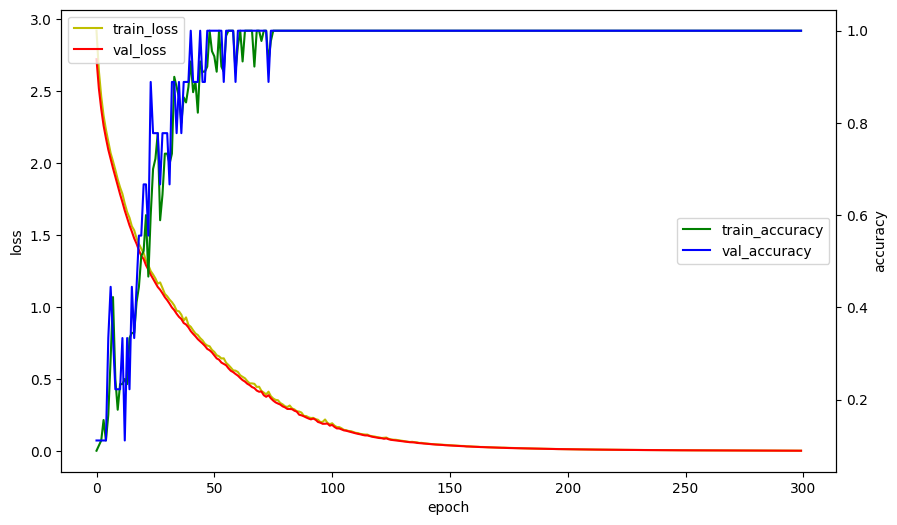

In [39]:
# 학습과정 표시하기
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc= 'center right')
plt.show()

In [42]:
# 모델 평가하기(테스트데이터셋으로 모델 설정과정의 loss, metrics)
score = model.evaluate(x_val,Y_val, batch_size=3)
print('loss :', score[0])
print('accuracy', score[1])

3/3 [==============================] - 0s 1ms/step - loss: 0.0036 - accuracy: 1.0000
loss : 0.0035822507925331593
accuracy 1.0


# 7.1 모델 사용하기(모델을 이용해서 예측하기)

In [47]:
H = model.predict(np.array([2]))
H.argmax()

1/1 [==============================] - 0s 16ms/step


4

In [46]:
model.predict(np.array([2])).argmax()

1/1 [==============================] - 0s 16ms/step


4

In [49]:
# 몇 %의 확률로 예측했나
H[0, H.argmax()]*100

99.72931742668152

In [50]:
# 2, 4, 6의 확률
H[0, [2,4,6]]*100

array([ 0.15435871, 99.72932   ,  0.1163251 ], dtype=float32)

# 7.2 모델 저장하기

In [51]:
model.save('model/02_deep.h5')

In [52]:
# 저장된 모델 사용하기
model1 = load_model('model/02_deep.h5')

In [53]:
model1.predict(np.array([3])).argmax()

1/1 [==============================] - 0s 44ms/step


6